### **Importing Libraries**

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np

### **Set-up and Data**

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 128
EPOCHS = 20
LEARNING_RATE = 1e-3
LATENT_DIM = 128
torch.manual_seed(42)
np.random.seed(42)

transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"Using device: {device}")
print(f"Loaded {len(train_dataset)} training images.")

Using device: cuda
Loaded 60000 training images.


### **Creating VAE**

In [15]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=128):
        super(VAE, self).__init__()
        
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

def vae_loss(recon_x, x, mu, logvar):
    recon_loss = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kld_loss, recon_loss, kld_loss

model = VAE(latent_dim=LATENT_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

### **Training**

In [16]:
history_total = []
history_recon = []
history_kld = []

model.train()
for epoch in range(EPOCHS):
    train_loss = 0
    recon_total = 0
    kld_total = 0
    
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        
        loss, recon, kld = vae_loss(recon_batch, data, mu, logvar)
        loss.backward()
        
        train_loss += loss.item()
        recon_total += recon.item()
        kld_total += kld.item()
        
        optimizer.step()
        
    avg_loss = train_loss / len(train_loader.dataset)
    avg_recon = recon_total / len(train_loader.dataset)
    avg_kld = kld_total / len(train_loader.dataset)
    
    history_total.append(avg_loss)
    history_recon.append(avg_recon)
    history_kld.append(avg_kld)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Total: {avg_loss:.2f} | Recon: {avg_recon:.2f} | KLD: {avg_kld:.2f}")

Epoch [1/20] | Total: 174.07 | Recon: 158.97 | KLD: 15.09
Epoch [2/20] | Total: 134.13 | Recon: 111.09 | KLD: 23.03
Epoch [3/20] | Total: 122.16 | Recon: 97.82 | KLD: 24.34
Epoch [4/20] | Total: 115.59 | Recon: 90.83 | KLD: 24.76
Epoch [5/20] | Total: 112.11 | Recon: 86.92 | KLD: 25.20
Epoch [6/20] | Total: 109.98 | Recon: 84.48 | KLD: 25.50
Epoch [7/20] | Total: 108.71 | Recon: 82.97 | KLD: 25.74
Epoch [8/20] | Total: 107.76 | Recon: 81.88 | KLD: 25.88
Epoch [9/20] | Total: 107.16 | Recon: 81.15 | KLD: 26.01
Epoch [10/20] | Total: 106.71 | Recon: 80.63 | KLD: 26.08
Epoch [11/20] | Total: 106.20 | Recon: 80.09 | KLD: 26.10
Epoch [12/20] | Total: 105.88 | Recon: 79.72 | KLD: 26.16
Epoch [13/20] | Total: 105.59 | Recon: 79.42 | KLD: 26.18
Epoch [14/20] | Total: 105.38 | Recon: 79.16 | KLD: 26.22
Epoch [15/20] | Total: 105.12 | Recon: 78.88 | KLD: 26.23
Epoch [16/20] | Total: 104.95 | Recon: 78.70 | KLD: 26.25
Epoch [17/20] | Total: 104.76 | Recon: 78.49 | KLD: 26.26
Epoch [18/20] | Total

### **Visualising the Losses**

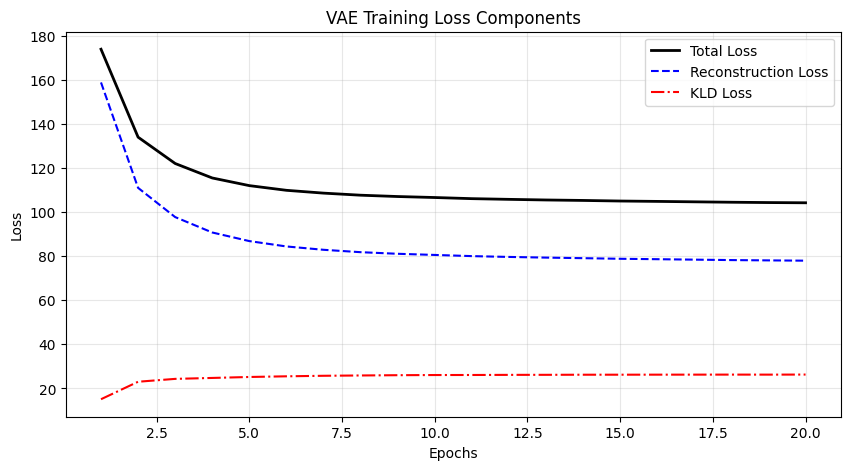

In [17]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, history_total, label='Total Loss', color='black', linewidth=2)
plt.plot(epochs_range, history_recon, label='Reconstruction Loss', color='blue', linestyle='--')
plt.plot(epochs_range, history_kld, label='KLD Loss', color='red', linestyle='-.')

plt.title('VAE Training Loss Components')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

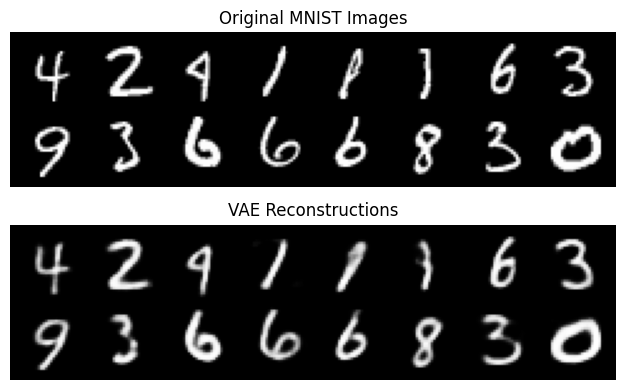

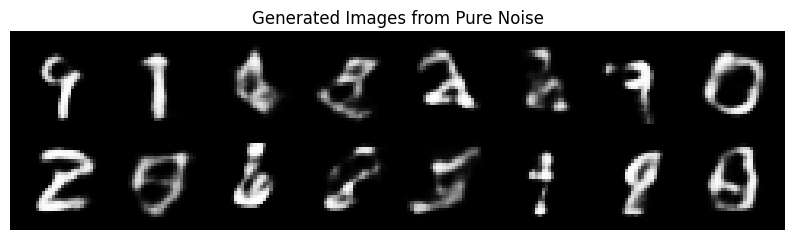

In [18]:
model.eval()
with torch.no_grad():
    data, _ = next(iter(train_loader))
    data = data.to(device)[:16]
    
    recon, _, _ = model(data)
    recon = recon.view(-1, 1, 28, 28)
    
    fig, axes = plt.subplots(2, 1, figsize=(10, 4))
    
    grid_real = vutils.make_grid(data, nrow=8, padding=2, normalize=True)
    axes[0].imshow(np.transpose(grid_real.cpu(), (1, 2, 0)))
    axes[0].set_title("Original MNIST Images")
    axes[0].axis('off')
    
    grid_recon = vutils.make_grid(recon, nrow=8, padding=2, normalize=True)
    axes[1].imshow(np.transpose(grid_recon.cpu(), (1, 2, 0)))
    axes[1].set_title("VAE Reconstructions")
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()
    
    z = torch.randn(16, LATENT_DIM).to(device)
    generated = model.decode(z).view(-1, 1, 28, 28)
    
    plt.figure(figsize=(10, 3))
    grid_gen = vutils.make_grid(generated, nrow=8, padding=2, normalize=True)
    plt.imshow(np.transpose(grid_gen.cpu(), (1, 2, 0)))
    plt.title("Generated Images from Pure Noise")
    plt.axis('off')
    plt.show()

In [20]:
def vae_loss_beta(recon_x, x, mu, logvar, beta=1.0):
    recon_loss = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kld_loss, recon_loss, kld_loss

def train_beta_vae(beta, epochs=20):
    torch.manual_seed(42)
    m = VAE(latent_dim=LATENT_DIM).to(device)
    opt = optim.Adam(m.parameters(), lr=LEARNING_RATE)
    m.train()
    for epoch in range(epochs):
        for data, _ in train_loader:
            data = data.to(device)
            opt.zero_grad()
            recon_batch, mu, logvar = m(data)
            loss, _, _ = vae_loss_beta(recon_batch, data, mu, logvar, beta=beta)
            loss.backward()
            opt.step()
    return m

beta_values = [1, 5, 20]
beta_models = {b: train_beta_vae(b) for b in beta_values}

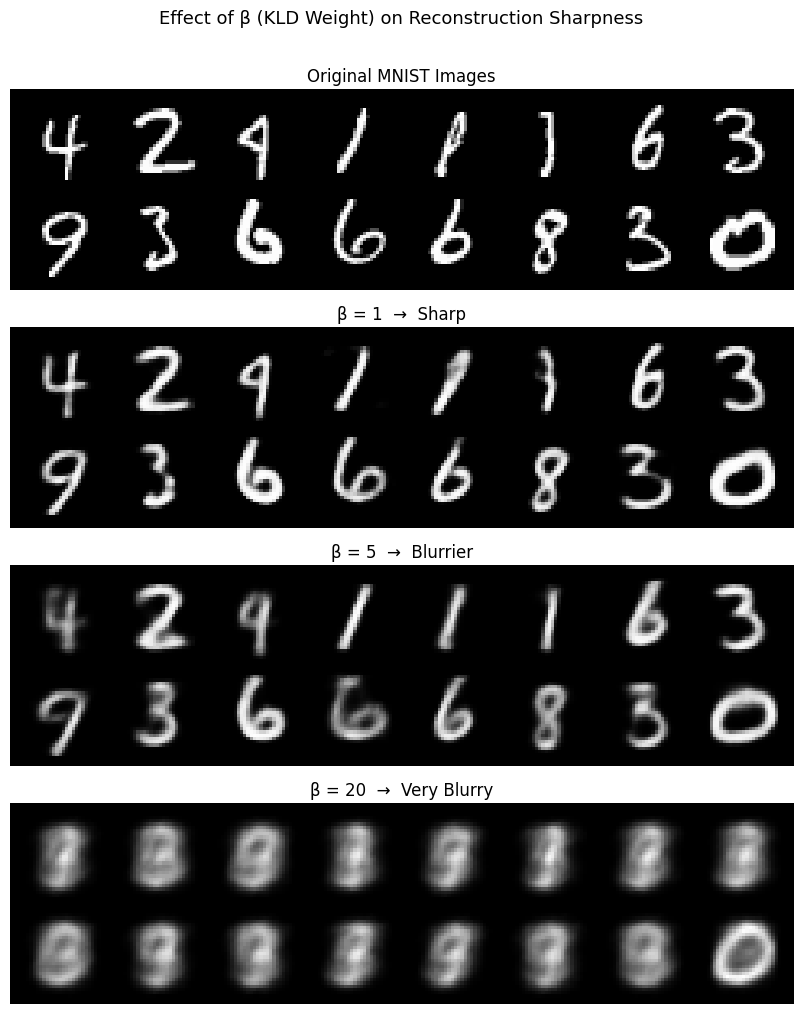

In [21]:
fig, axes = plt.subplots(len(beta_values) + 1, 1, figsize=(12, 2.5 * (len(beta_values) + 1)))

sample_data, _ = next(iter(train_loader))
sample_data = sample_data.to(device)[:16]

grid_real = vutils.make_grid(sample_data, nrow=8, padding=2, normalize=True)
axes[0].imshow(np.transpose(grid_real.cpu(), (1, 2, 0)))
axes[0].set_title("Original MNIST Images")
axes[0].axis('off')

for i, beta in enumerate(beta_values):
    m = beta_models[beta]
    m.eval()
    with torch.no_grad():
        recon, _, _ = m(sample_data)
        recon = recon.view(-1, 1, 28, 28)
    grid = vutils.make_grid(recon, nrow=8, padding=2, normalize=True)
    axes[i + 1].imshow(np.transpose(grid.cpu(), (1, 2, 0)))
    axes[i + 1].set_title(f"β = {beta}  →  {'Sharp' if beta == 1 else 'Blurrier' if beta == 5 else 'Very Blurry'}")
    axes[i + 1].axis('off')

plt.suptitle("Effect of β (KLD Weight) on Reconstruction Sharpness", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()